In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/paramvir705/netflix-dataset/netflix_titles.csv


### Data Location and Organization
The data for this case study is a publicly available dataset reflecting a specific historical period of content activity on the Netflix platform. The data is structured in a tabular format (such as a CSV file), where each row represents a unique title available on the platform (identified by a unique `show_id`). The columns capture key features of the content, including its type (Movie or TV Show), title, director, cast, country of origin, date added to the platform, release year, age rating, duration, genres (`listed_in`), and a brief description.

### Data Credibility and Bias
Because this dataset tracks actual historical listings on the Netflix platform, it provides a highly reliable snapshot of the company's catalog during that specific period. However, we must account for inherent sample biases. The data strictly reflects content that survived licensing agreements and remained on the platform during the collection window; it does not represent the entire history of global entertainment, nor does it capture real-time viewer preferences, as it lacks user engagement metrics like watch time or view counts.

### Licensing, Privacy, Security, and Accessibility
The dataset is utilized under open public data terms, allowing for analytical and educational exploration. Privacy is inherently preserved, as the data focuses entirely on public media catalog information and contains no personally identifiable information (PII) regarding Netflix subscribers. Data security involves storing the dataset in a secure local or cloud workspace to prevent corruption. Accessibility ensures that the resulting insights and data visualizations are structured clearly for project stakeholders.

### Data Integrity and Authenticity Concerns
A significant challenge to the data's integrity is the high volume of missing or unavailable (`NaN`) data, particularly in the `director` and `cast` columns. This missingness raises critical questions regarding data authenticity and completeness. It suggests that the data collection method may have relied on automated scraping that struggled with regional content, or that Netflix's own metadata metadata was incomplete for certain independent or international titles. To verify integrity, exploratory data analysis (EDA) must be performed to quantify these gaps and ensure that missing values do not systematically skew our conclusions.

### Relevance to the Business Questions
Despite the missing metadata, the core columns needed to address the primary business objectives remain highly intact.
* **To determine content dominance:** The `type` column is fully populated.
* **To map geographic contribution:** The `country` column provides sufficient data points, though it will require cleaning for multi-country co-productions.
* **To find frequently appearing actors:** The `cast` column can still be parsed and counted, though our insights will explicitly carry the caveat that they only represent "known/listed" cast members.

### Potential Problems
* **Missing Metadata:** The absence of directors and cast members significantly limits our ability to map creative networks accurately.
* **Format Inconsistencies:** The `duration` column uses mixed metrics—measuring Movies in minutes and TV Shows in seasons—which prevents a direct numerical comparison of content length without prior transformation.
* **Lack of Performance Data:** The dataset lacks user ratings, viewership numbers, or completion rates, meaning we can analyze what content Netflix *offered*, but not what content users actually *watched*.

### Key Tasks
1. **Download and Secure Data:** Import the dataset into a reliable analytical environment (such as a Jupyter Notebook or SQL database) and back up the raw file.
2. **Assess Structure and Gaps:** Audit the dataset to map out the exact percentage of missing values per column, focusing heavily on the `director` and `cast` fields to determine the boundary of our analysis.
3. **Clean, Filter, and Transform:**
    * Filter out or isolate rows with missing values where necessary.
    * Split comma-separated strings in the `country` and `cast` columns so that individual actors and countries can be accurately counted and ranked.
    * Separate the dataset into distinct data frames for Movies and TV Shows to handle the differing `duration` formats smoothly.

# 🧰Importing Necessary Libraries

In [2]:
# Importing Data Science Libraries
import numpy as np
import pandas as pd
import os

# Importing Visualization Libraries
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as px
import missingno as msno
import plotly.offline as pyo 
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots

plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

# 🧰Importing the Dataset

In [3]:
# Define the file path
file_path = '/kaggle/input/datasets/paramvir705/netflix-dataset/netflix_titles.csv'

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows to verify it loaded correctly
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
# Calculate missing percentage per column
missing_percentage = (df.isnull().mean() * 100).reset_index()
missing_percentage.columns = ['column', 'missing_percentage']

# Sort for better readability
missing_percentage = missing_percentage.sort_values(by='missing_percentage', ascending=True)

# Create bar chart
fig = px.bar(
    missing_percentage,
    x='missing_percentage',
    y='column',
    orientation='h',
    title='Data Inconsistency: Missing Values Percentage by Column',
    labels={'missing_percentage': 'Missing Values (%)', 'column': 'Dataset Columns'}
)

# Improve layout clarity
fig.update_layout(
    xaxis_range=[0, 100],
    yaxis_title='',
    xaxis_title='Missing Data (%)'
)

fig.show()

### Missing Data

We have missing data in the `director`, `country`, and `cast` columns. Visual inspection of the graph above highlights these gaps. Because the missing information is significant, we need to carefully decide whether to impute these data points or simply drop them.

### Fixing Data Types and Removing Duplicates

We imputed the missing values by replacing them with "unknown" for the `director`, `cast` (or `actors`), and `country` columns.

In [5]:
# 2. Define a dictionary mapping columns to their respective replacement values
imputation_values = {
    'director': 'Unknown Director',
    'cast': 'Unknown Cast',
    'country': 'Unknown Country'
}

# 3. Fill the missing (NaN) values
df.fillna(value=imputation_values, inplace=True)

# 4. Verify that the missing values in these columns have been resolved
print(df[['director', 'cast', 'country']].isna().sum())

director    0
cast        0
country     0
dtype: int64


### Data Cleanliness Check

Now, there should be no missing data in our dataset.

### 4. Standardizing the 'Duration' Column

The `duration` column contains mixed formats, representing minutes (`min`) for movies and season counts (`Seasons`) for TV shows. To prepare this data for precise analysis, we extract the numeric digits from the original duration strings. From this extracted data, we create two separate, clean numeric columns: one dedicated to movie durations in minutes and another for TV show durations by the number of seasons. Once these new metrics are successfully generated, the temporary calculation columns are dropped to keep the dataset clean and organized.

### 5. Sanity Check & Verification

With the transformations complete, a final sanity check is performed to verify that the split was executed correctly, ensure no data was lost, and confirm that the dataset is now structurally sound for analysis.

In [6]:
df.dropna(subset=['date_added', 'duration'], inplace=True)

# 3. Standardize text data (Remove hidden spaces & fix casing)
text_columns = ['title', 'type', 'rating', 'listed_in', 'description']
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

# -------------------------------------------------------------------------
# 4. Standardize the 'duration' column
# -------------------------------------------------------------------------
# The 'duration' column contains both "min" (Movies) and "Seasons" (TV Shows). 
# We will create two separate, clean numeric columns for precise analysis.

# Extract the numeric digits from the duration string
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

# Create a clean Movie duration column (in minutes)
df['movie_duration_min'] = np.where(df['type'] == 'Movie', df['duration_num'], np.nan)

# Create a clean TV Show duration column (number of seasons)
df['tv_seasons'] = np.where(df['type'] == 'TV Show', df['duration_num'], np.nan)

# Drop the temporary calculation column
df.drop(columns=['duration_num'], inplace=True)


# -------------------------------------------------------------------------
# 5. Sanity Check / Verification
# -------------------------------------------------------------------------
print("--- Missing Values Remaining ---")
print(df.isna().sum())

print("\n--- Data Types Check ---")
print(df.dtypes)

--- Missing Values Remaining ---
show_id                  0
type                     0
title                    0
director                 0
cast                     0
country                  0
date_added               0
release_year             0
rating                   0
duration                 0
listed_in                0
description              0
movie_duration_min    2666
tv_seasons            6128
dtype: int64

--- Data Types Check ---
show_id                object
type                   object
title                  object
director               object
cast                   object
country                object
date_added             object
release_year            int64
rating                 object
duration               object
listed_in              object
description            object
movie_duration_min    float64
tv_seasons            float64
dtype: object


### Visualizing Content Distribution and Duration Types

To better understand the composition of our dataset, we first extract the exact distribution of content types based on the missing values within our newly standardized columns. Specifically, the `movie_duration_min` column contains 2,666 missing values, which explicitly identifies those entries as TV Shows. Conversely, the `tv_seasons` column has 6,128 missing values, revealing that those entries represent Movies. 

Using these precise counts, we will construct a single, clean donut chart to visually compare the proportion of Movies versus TV Shows. To ensure a sleek and professional design, the percentage text inside each slice will be styled in a readable white font. Additionally, we will transform the standard pie chart into a modern donut chart by embedding a crisp white center circle, followed by final adjustments to the title and layout spacing for optimal presentation.

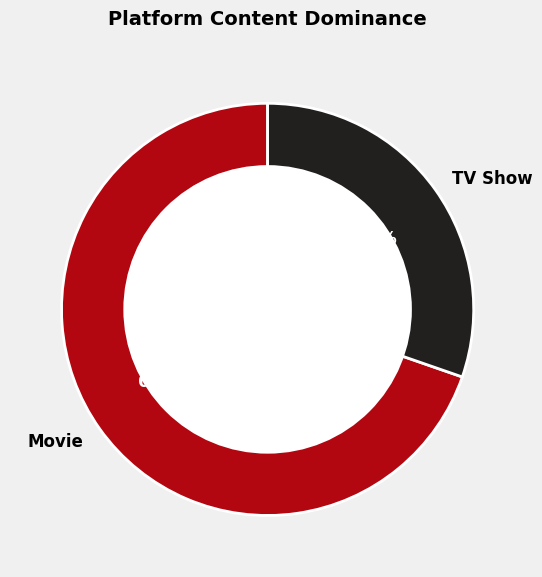

In [7]:
# 1. Extract your exact counts from the data you provided
# movie_duration_min has 2666 missing values -> means 2666 are TV Shows
# tv_seasons has 6128 missing values -> means 6128 are Movies
type_counts = {"Movie": 6128, "TV Show": 2666}

labels = list(type_counts.keys())
sizes = list(type_counts.values())

# 2. Create a single, clean Donut/Pie Chart
fig, ax = plt.subplots(figsize=(6, 6))
colors = ["#b20710", "#221f1f"]  # Premium streaming palette (Red & Dark Grey)

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 2, "antialiased": True},
    textprops={"fontsize": 12, "weight": "bold"},
)

# Style the percentage text inside the slices to be white and readable
for autotext in autotexts:
    autotext.set_color("white")

# Turn the pie chart into a modern donut chart by adding a center circle
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig.gca().add_artist(centre_circle)

# Adjust title and spacing
ax.set_title("Platform Content Dominance", fontsize=14, weight="bold", pad=20)
plt.tight_layout()
plt.show()

* **Movie Dominance:** The donut chart highlights that movies currently dominate the platform, driven by a high volume of content and strong viewer demand.
* **Strategic Growth Opportunity:** To build long-term platform health, the service should invest in the TV show category to attract dedicated, loyal subscribers and create a more balanced ecosystem.

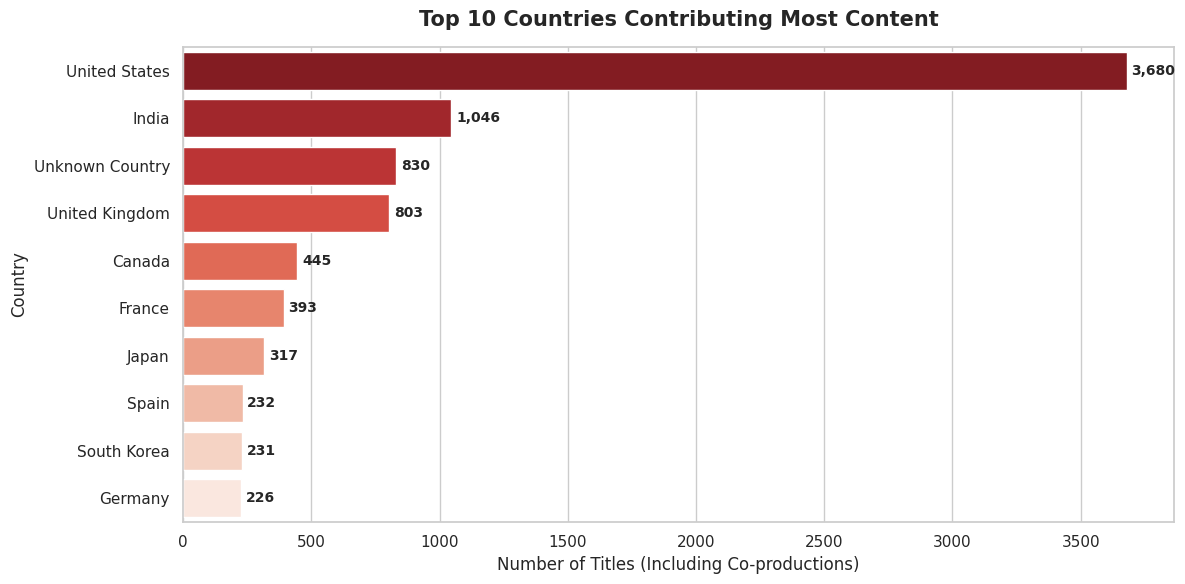

In [8]:
# Set clean style for the chart
sns.set_theme(style="whitegrid")

# 1. Clean and split the country column
# Drop missing values in country just for this calculation, then split by comma
country_series = df["country"].dropna().str.split(", ")

# Explode converts a list of countries [US, UK] into separate rows for accurate counting
all_countries = country_series.explode()

# Strip any residual whitespace and get the top 10 countries
top_countries = all_countries.str.strip().value_counts().head(10)

# 2. Create the Bar Chart Visualization
plt.figure(figsize=(12, 6))

# Using a sleek gradient palette to keep it looking premium
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="Reds_r",
    hue=top_countries.index,
    legend=False,
)

# Customizing titles and labels
plt.title(
    "Top 10 Countries Contributing Most Content", fontsize=15, weight="bold", pad=15
)
plt.xlabel("Number of Titles (Including Co-productions)", fontsize=12)
plt.ylabel("Country", fontsize=12)

# Add exact value labels to the end of each bar
for i, val in enumerate(top_countries.values):
    plt.text(
        val + (max(top_countries.values) * 0.005),
        i,
        f"{val:,}",
        va="center",
        fontsize=10,
        weight="bold",
    )

plt.tight_layout()
plt.show()

### Top 10 Countries Contributing Most Content
The horizontal bar chart clearly shows the dominance of content production across countries on the platform.

### Key Observations
* **United States** leads overwhelmingly with 3,680 titles, more than triple the second-ranked country.
* **India** follows at a distant 1,046, demonstrating strong South Asian representation.
* **United Kingdom** (803) and **Unknown Country** (830) form the next tier, with "Unknown" likely representing unclassified or multi-country co-productions.
* **The remaining countries** (Canada, France, Japan, Spain, South Korea, Germany) contribute between 226–445 titles each, showing a significant drop-off after the top four.

### Insights
The platform’s content is heavily skewed toward Western (especially American) and Indian productions. The US alone accounts for a massive share, highlighting Hollywood’s continued global influence. India’s strong second position reflects the growing impact of Bollywood and regional Indian cinema.

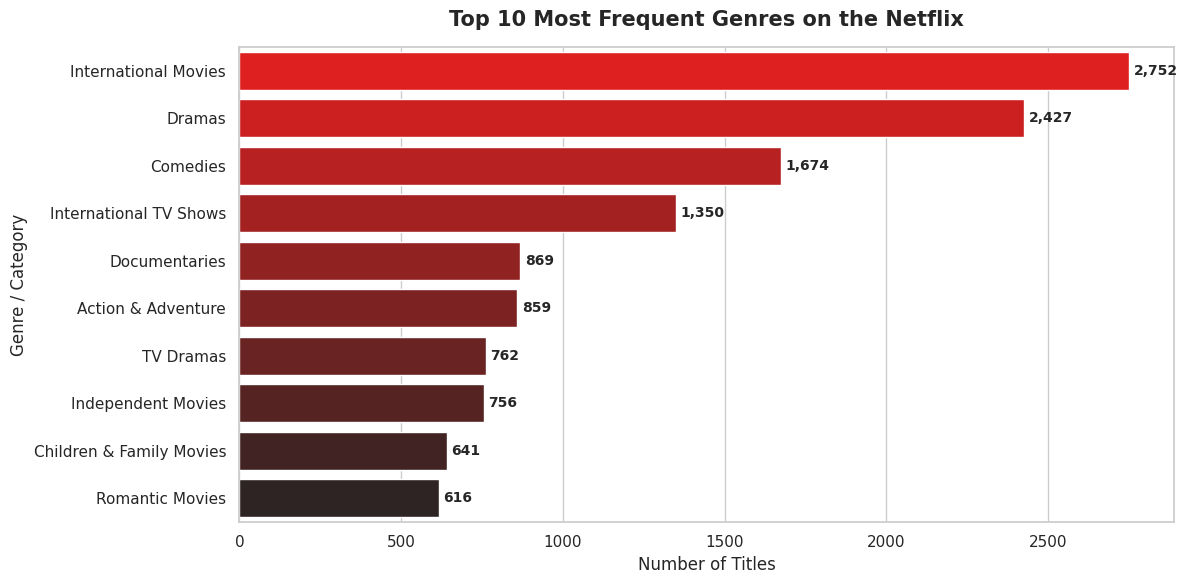

In [9]:
# Set a clean theme for the chart
sns.set_theme(style="whitegrid")

# 1. Clean and split the 'listed_in' column
# Split genres by comma and expand them into individual rows
genre_series = df["listed_in"].dropna().str.split(", ")
all_genres = genre_series.explode()

# Strip any accidental whitespace and get the top 10 most frequent genres
top_genres = all_genres.str.strip().value_counts().head(10)

# 2. Create the Bar Chart Visualization
plt.figure(figsize=(12, 6))

# Using a deep red/dark palette matching the streaming vibe
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette="dark:red_r",
    hue=top_genres.index,
    legend=False,
)

# Customizing titles and labels
plt.title(
    "Top 10 Most Frequent Genres on the Netflix", fontsize=15, weight="bold", pad=15
)
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Genre / Category", fontsize=12)

# Add exact value labels to the end of each bar
for i, val in enumerate(top_genres.values):
    plt.text(
        val + (max(top_genres.values) * 0.005),
        i,
        f"{val:,}",
        va="center",
        fontsize=10,
        weight="bold",
    )

plt.tight_layout()
plt.show()

### Top 10 Most Frequent Genres on the Platform
The horizontal bar chart reveals the platform’s genre distribution by number of titles.

### Key Observations
* **International Movies** lead strongly with 2,752 titles — the most dominant category.
* **Dramas** follow closely at 2,427, showing very high representation.
* **Comedies** (1,674) and **International TV Shows** (1,350) form the next significant tier.
* **There’s a clear drop after the top 4**, with the remaining genres (Documentaries through Romantic Movies) ranging between 616–869 titles.

### Insights
The platform’s content leans heavily toward International Movies and Dramas, indicating a strong global appeal combined with emotionally driven storytelling. Comedy provides solid entertainment value, while International TV Shows show a meaningful presence in episodic content.

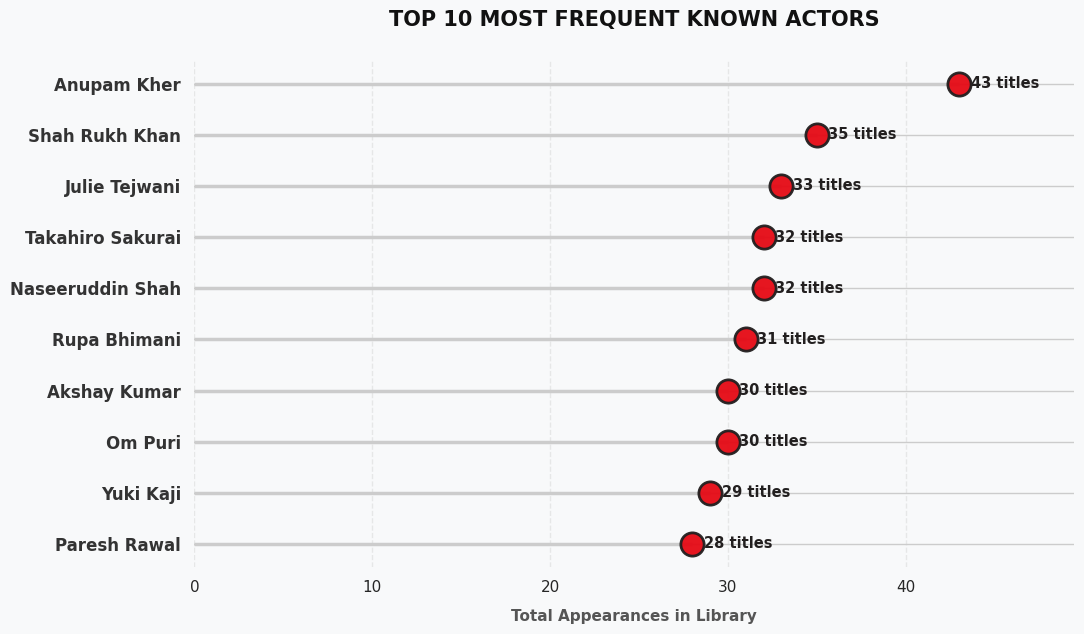

In [10]:
# 1. Clean and process the cast data
cast_series = df["cast"].dropna().replace("", np.nan).dropna().str.split(", ")
all_actors = cast_series.explode().str.strip()

# Get a larger pool of top entries so we can drop "Unknown Cast" safely
top_actors = all_actors.value_counts().head(15)

# Drop "Unknown Cast" (and variations) to solve the scale compression issue
strings_to_drop = ["Unknown Cast", "Unknown", "nan", "Missing"]
top_actors = top_actors.drop(labels=strings_to_drop, errors="ignore").head(10)

# 2. Create the Fixed, Presentation-Ready Lollipop Chart
fig, ax = plt.subplots(figsize=(11, 6.5), facecolor="#F8F9FA")
ax.set_facecolor("#F8F9FA")

# Sort data so the highest appearance is at the very top
top_actors = top_actors.iloc[::-1]
y_range = np.arange(len(top_actors))

# Draw the background lines (the lollipop sticks)
ax.hlines(
    y=y_range,
    xmin=0,
    xmax=top_actors.values,
    color="#CCCCCC",
    linestyle="-",
    linewidth=2.5,
    zorder=1,
)

# Draw the stylized data endpoints (the lollipops)
ax.scatter(
    top_actors.values,
    y_range,
    color="#E50914",  # Bold streaming-platform red
    s=280,
    edgecolor="#221F1F",
    linewidth=2,
    alpha=0.95,
    zorder=2,
)

# Add clear data labels directly next to the endpoints
# (Fixed padding dynamically using the new maximum value)
max_val = max(top_actors.values)
for i, val in enumerate(top_actors.values):
    ax.text(
        val + (max_val * 0.015),
        i,
        f"{val} titles",
        va="center",
        ha="left",
        fontsize=10.5,
        fontweight="bold",
        color="#221F1F",
    )

# 3. Clean styling and typography
ax.set_yticks(y_range)
ax.set_yticklabels(top_actors.index, fontsize=12, fontweight="bold", color="#333333")

# Title styling
ax.set_title(
    "TOP 10 MOST FREQUENT KNOWN ACTORS",
    fontsize=15,
    fontweight="black",
    color="#111111",
    pad=25,
)

# Axis adjustments - the scale now beautifully spans roughly 0 to 45 instead of 0 to 850
ax.set_xlabel("Total Appearances in Library", fontsize=11, fontweight="bold", color="#555555", labelpad=10)
ax.set_xlim(0, max_val * 1.15)  
ax.grid(axis="x", linestyle="--", alpha=0.4, color="#CCCCCC")

# Strip down the container frames for a modern flat look
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Top 10 Most Frequent Known Actors
The lollipop-style chart highlights the actors with the highest number of titles available on the platform.

### Key Observations
* **Anupam Kher** leads comfortably with 43 titles, making him the most prolific actor in the catalog.
* **Shah Rukh Khan** ranks second with 35 titles, showing a strong Bollywood presence.
* **The top 10 is tightly clustered** between 28–43 titles, indicating several highly represented actors.
* **Notable mix:** Strong Indian cinema representation (Anupam Kher, SRK, Naseeruddin Shah, Akshay Kumar, Om Puri, Paresh Rawal) alongside international names like Japanese voice actors Takahiro Sakurai (32) and Yuki Kaji (29).

### Insights
The actor distribution reinforces the platform’s heavy focus on Indian content and International Movies. Veteran actors with massive filmographies dominate, suggesting the catalog includes extensive back catalogs and popular mainstream titles.

## Key Takeaways & Relevance to Business Question

### Overall Key Takeaways
* **Strong Movie Dominance:** Movies significantly outweigh TV Shows on the platform. This indicates the catalog is heavily oriented toward feature films rather than episodic content.
* **Geographic Concentration:** The United States leads by a massive margin (3,680 titles), followed by India (1,046). Together with the UK, these three (plus “Unknown”) dominate content volume. The rest of the top 10 shows moderate but much smaller contributions from countries like Canada, France, Japan, and South Korea.
* **Genre Preferences:** International Movies and Dramas are the two most frequent categories, followed by Comedies and International TV Shows. This points to a catalog built around broad-appeal, globally accessible storytelling with strong emotional and cross-cultural resonance.
* **Actor Concentration:** Indian cinema veterans dominate the top actors list (Anupam Kher – 43 titles, Shah Rukh Khan – 35 titles, etc.). The presence of Japanese voice actors (Takahiro Sakurai, Yuki Kaji) further reinforces the strength of International/Anime content.

> **Data Notes:**
> * Content type data is complete and reliable.
> * Country data requires cleaning for co-productions.
> * Actor insights are based on listed/known cast members only.

---

### Relevance to Our Business Question
> **Business Question Context:**
> *“How is our current content portfolio structured, and what strategic opportunities or risks exist for improving content acquisition, user engagement, and long-term platform growth?”*

#### Strategic Implications:

* **Content Acquisition Strategy**  
  The platform is heavily dependent on Hollywood and Bollywood libraries. While this provides high volume and proven appeal, it creates vulnerability to rising licensing costs and competition. Opportunity exists to intentionally grow mid-tier countries (Japan, South Korea, France, Spain) to increase diversity and reduce reliance on the top two markets.

* **Genre & Format Balance**  
  The clear preference for International Movies and Dramas explains the movie-heavy donut chart. However, TV Shows (especially International TV) still hold a meaningful presence. Prioritizing high-quality drama-driven series could help increase user retention and session time, as TV content typically drives longer-term engagement compared to one-off movies.

* **Audience Targeting & Personalization**  
  The strong Indian and International Movie presence suggests the platform has significant traction among global audiences who prefer non-English or multi-language content with universal themes. Marketing and recommendation systems should lean into “International Hits” and “Drama Spotlight” collections.

#### Risks Identified
* Over-reliance on a small number of countries and actors may limit cultural breadth.
* If “Unknown Country” represents many co-productions, actual geographic diversity might be understated.
* Heavy dependence on established actors with large filmographies risks catalog aging if newer talent is not consistently added.

#### Growth Opportunities
* Invest in original or licensed International Dramas and International TV Shows to balance the current movie skew.
* Leverage top actors (especially Anupam Kher & SRK) for targeted campaigns in key markets.
* Explore expansion in high-potential regions like South Korea and Japan, where content is already performing well but volume is still relatively low.

---

### Bottom Line:
The platform currently enjoys a volume-heavy, internationally flavored, movie-dominant catalog that performs strongly in broad-appeal genres. This is a solid foundation, but sustainable growth will require deliberate efforts to increase TV Show representation, diversify country sources beyond the US-India duopoly, and maintain freshness in the actor pool. These insights provide a clear direction for data-driven content strategy decisions.

## Recommendations to Improve Netflix Viewers

Based on the analyzed insights — movie-dominant catalog, US + India heavy geographic concentration, strong International Movies & Dramas, and prominent Indian + select international actors — here are targeted, data-driven recommendations to grow audience size, engagement, and retention.

### 1. Balance Content Portfolio (Movies vs TV Shows)
* **Current Issue:** Movies significantly dominate TV Shows, which limits long-term viewer retention.
* **Recommendations:**
  * Increase investment in *International TV Shows* and *TV Dramas* (currently ranked 4th and 7th). These drive higher completion rates and habit-forming viewing.
  * Launch “International Drama Bundles” or “Global Series Club” featuring high-quality non-English series from South Korea, Japan, Spain, and France.
  * Aim for a more balanced **60:40** or **55:45** Movie-to-TV ratio over 2–3 years.
* **Expected Impact:** Longer average session times and improved subscriber retention, especially among dedicated viewers.

### 2. Diversify Geographic Content Sources
* **Current Issue:** Extreme dependence on the US (3,680 titles) and India (1,046), with a sharp drop afterward.
* **Recommendations:**
  * Aggressively expand licensing and original productions from high-potential mid-tier countries (Japan, South Korea, France, Spain, Canada).
  * Develop regional content hubs in Southeast Asia, Latin America, and Africa to tap into underserved markets with growing internet penetration.
  * Clean and better utilize “Unknown Country” data to identify and promote strong co-productions.
* **Expected Impact:** Broader global appeal, reduced licensing risk, and access to new subscriber pools in emerging markets.

### 3. Leverage & Expand Top Genres and Talent
* **Current Strength:** International Movies and Dramas lead, backed by prolific actors like Anupam Kher and Shah Rukh Khan.
* **Recommendations:**
  * Create flagship collections such as:
    * *“International Movie Hits”*
    * *“Powerful Dramas from Around the World”*
    * *“Bollywood Legends”* (featuring Anupam Kher, SRK, Akshay Kumar, etc.)
  * Capitalize on Japanese voice actors (Takahiro Sakurai, Yuki Kaji) by strengthening Anime and International Animation offerings.
  * Commission original content that blends popular genres — e.g., International Romantic Dramas or Action-Comedies with cross-cultural appeal.
* **Expected Impact:** Higher discoverability, stronger personalization signals, and increased watch time through familiar, high-quality content.

---

### 4. Audience Segmentation & Personalization Strategies
* **Casual Viewers** *(likely movie-dominant)*: Improve homepage recommendations with high-engagement International Movies and Comedies.
* **Dedicated Viewers**: Push TV Dramas and International TV Shows with “Next Episode” autoplay and season bundles.
* **Targeted Campaigns**: Run campaigns in India and Indian diaspora markets using top actors, while creating parallel campaigns in Europe and East Asia highlighting Japanese/Korean/French content.

### 5. Marketing & User Acquisition Tactics
* **Leverage Star Power:** Partner with Anupam Kher, Shah Rukh Khan, and rising international stars for global and regional ad campaigns.
* **Genre-Led Campaigns:** Promote “International Movies” as Netflix’s unique strength versus competitors.
* **Free Trials & Promotions:** Offer genre-specific or country-specific trial extensions (e.g., “30 Days of Indian Cinema” or “K-Drama Starter Pack”).
* **Social & Viral Push:** Create short clips and challenges featuring popular scenes from top dramas and international movies.

### 6. Long-term Strategic Considerations
* **Risk Mitigation:** Reduce over-reliance on Hollywood and Bollywood by setting internal targets for content from the next 10 countries.
* **Freshness:** Actively add newer talent and emerging directors to prevent catalog aging.

> #### Measurement KPIs
> * Monthly active viewers / hours watched
> * Subscriber growth by region and content type
> * Retention rate by genre preference
> * Completion rates for TV Shows vs Movies